# 01 — Análisis Exploratorio de Datos (EDA)
## LoanRisk-ML

En este notebook exploramos el dataset de Lending Club para entender su estructura,
calidad y características antes de construir el modelo de scoring crediticio.

### Objetivos
- Entender la distribución del target (default rate)
- Identificar y eliminar columnas con data leakage
- Analizar valores faltantes y decidir estrategia de limpieza
- Explorar variables categóricas y numéricas
- Analizar el default rate por grade y por año


## 1. Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 2. Configuración visual y de display

In [2]:
%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Configuración aplicada")

Configuración aplicada


## 3. Rutas del proyecto

Usamos `pathlib` para manejar rutas de forma limpia sin exponer rutas absolutas de la máquina.

In [3]:
ROOT = Path('..').resolve()
DATA_RAW = ROOT / 'data' / 'raw'
DATA_PROCESSED = ROOT / 'data' / 'processed'

print(f"Raíz del proyecto: {ROOT.name}")

Raíz del proyecto: loanrisk-ml


## 4. Carga del dataset

Cargamos 500K filas para exploración inicial. El dataset completo tiene ~2.2M filas.
Para EDA no necesitamos todas las filas — 500K es representativo y corre rápido.

In [4]:
df = pd.read_csv(DATA_RAW / 'accepted_2007_to_2018Q4.csv',
                 nrows=500_000,
                 low_memory=False)

print(f"Shape: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

Shape: (500000, 151)
Columnas: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_s

## 5. Primera vista del dataset

In [5]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,...,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0000,3600.0000,3600.0000,36 months,13.9900,123.0300,C,C4,leadman,10+ years,MORTGAGE,55000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.9100,0.0000,Aug-2003,675.0000,679.0000,1.0000,30.0000,NaN,7.0000,0.0000,2765.0000,29.7000,13.0000,w,0.0000,0.0000,4421.7239,4421.7200,3600.0000,821.7200,0.0000,0.0000,0.0000,Jan-2019,122.6700,NaN,...,4.0000,7.0000,0.0000,0.0000,0.0000,3.0000,76.9000,0.0000,0.0000,0.0000,178050.0000,7746.0000,2400.0000,13734.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0000,24700.0000,24700.0000,36 months,11.9900,820.2800,C,C1,Engineer,10+ years,MORTGAGE,65000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.0600,1.0000,Dec-1999,715.0000,719.0000,4.0000,6.0000,NaN,22.0000,0.0000,21470.0000,19.2000,38.0000,w,0.0000,0.0000,25679.6600,25679.6600,24700.0000,979.6600,0.0000,0.0000,0.0000,Jun-2016,926.3500,NaN,...,5.0000,22.0000,0.0000,0.0000,0.0000,2.0000,97.4000,7.7000,0.0000,0.0000,314017.0000,39475.0000,79300.0000,24667.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0000,20000.0000,20000.0000,60 months,10.7800,432.6600,B,B4,truck driver,10+ years,MORTGAGE,63000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.7800,0.0000,Aug-2000,695.0000,699.0000,0.0000,NaN,NaN,6.0000,0.0000,7869.0000,56.2000,18.0000,w,0.0000,0.0000,22705.9243,22705.9200,20000.0000,2705.9200,0.0000,0.0000,0.0000,Jun-2017,15813.3000,NaN,...,3.0000,6.0000,0.0000,0.0000,0.0000,0.0000,100.0000,50.0000,0.0000,0.0000,218418.0000,18696.0000,6200.0000,14877.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0000,35000.0000,35000.0000,60 months,14.8500,829.9000,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0000,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidati

## 6. Análisis del target

Exploramos la distribución de `loan_status` antes de definir el target binario.
Solo usaremos préstamos con resultado definitivo conocido: `Fully Paid` y `Charged Off`.

In [6]:
print("Distribución de loan_status:")
print(df['loan_status'].value_counts())
print()
print("Porcentaje:")
print(df['loan_status'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Distribución de loan_status:
loan_status
Fully Paid            312340
Current               104240
Charged Off            78824
Late (31-120 days)      2977
In Grace Period         1046
Late (16-30 days)        567
Default                    4
Name: count, dtype: int64

Porcentaje:
loan_status
Fully Paid            62.47%
Current               20.85%
Charged Off           15.76%
Late (31-120 days)      0.6%
In Grace Period        0.21%
Late (16-30 days)      0.11%
Default                 0.0%
Name: proportion, dtype: object


## 7. Definición del target binario

- `Fully Paid` → 0 (no default)
- `Charged Off` → 1 (default)

Eliminamos estados ambiguos como `Current`, `Late`, `In Grace Period` porque
no sabemos aún si van a defaultear o no.

In [7]:
status_map = {
    'Fully Paid': 0,
    'Charged Off': 1
}

df_model = df[df['loan_status'].isin(status_map.keys())].copy()
df_model['target'] = df_model['loan_status'].map(status_map)

print(f"Filas originales:     {len(df):,}")
print(f"Filas para el modelo: {len(df_model):,}")
print(f"Filas eliminadas:     {len(df) - len(df_model):,}")
print()
print(f"Default rate: {df_model['target'].mean():.2%}")
print(f"  - No default (0): {(df_model['target'] == 0).sum():,}")
print(f"  - Default    (1): {(df_model['target'] == 1).sum():,}")

Filas originales:     500,000
Filas para el modelo: 391,164
Filas eliminadas:     108,836

Default rate: 20.15%
  - No default (0): 312,340
  - Default    (1): 78,824


## 8. Visualización del desbalance del target

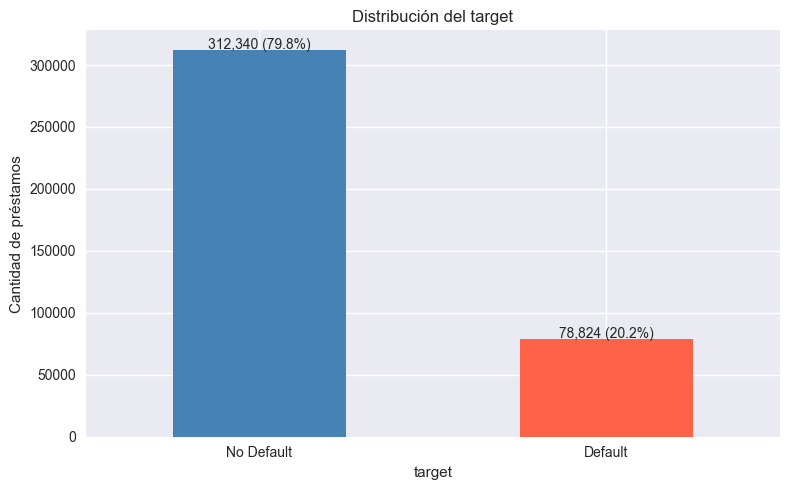

In [8]:
target_labels = df_model['target'].map({0: 'No Default', 1: 'Default'})
counts = target_labels.value_counts()

ax = counts.plot(kind='bar', color=['steelblue', 'tomato'], figsize=(8, 5))
ax.set_title('Distribución del target')
ax.set_ylabel('Cantidad de préstamos')
plt.xticks(rotation=0)

for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,} ({v/len(df_model)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

## 9. Análisis de valores faltantes

El porcentaje de nulos determina la estrategia:
- **>50%** → eliminar la columna
- **5-50%** → evaluar caso por caso
- **<5%** → imputar

In [9]:
missing = df_model.isnull().sum()
missing_pct = (missing / len(df_model) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

missing_df = missing_df[missing_df['missing_pct'] > 0]

print(f"Columnas con valores faltantes: {len(missing_df)}")
print()
print(missing_df.head(30))

Columnas con valores faltantes: 71

                                            missing_count  missing_pct
member_id                                          391164     100.0000
next_pymnt_d                                       391164     100.0000
desc                                               391122      99.9900
sec_app_mths_since_last_major_derog                390385      99.8000
orig_projected_additional_accrued_interest         389742      99.6400
hardship_length                                    389288      99.5200
hardship_status                                    389288      99.5200
deferral_term                                      389288      99.5200
hardship_end_date                                  389288      99.5200
hardship_reason                                    389288      99.5200
hardship_start_date                                389288      99.5200
hardship_type                                      389288      99.5200
hardship_loan_status                     

## 10. Visualización de valores faltantes

La línea punteada en 50% es el umbral de decisión —
columnas a la derecha son candidatas directas a eliminación.

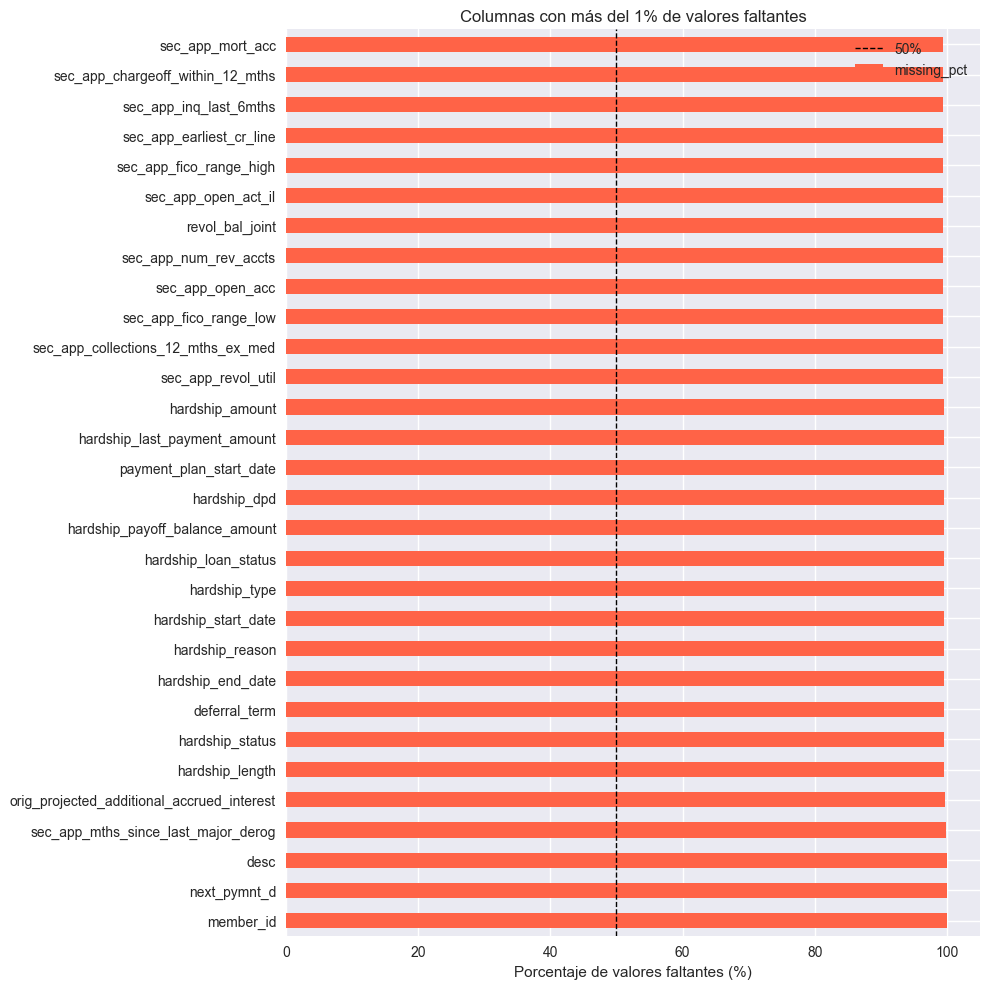

In [10]:
missing_plot = missing_df[missing_df['missing_pct'] > 1].head(30)

missing_plot['missing_pct'].plot(kind='barh', figsize=(10, 10), color='tomato')
plt.title('Columnas con más del 1% de valores faltantes')
plt.xlabel('Porcentaje de valores faltantes (%)')
plt.axvline(x=50, color='black', linestyle='--', linewidth=1, label='50%')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Eliminación de columnas con alto porcentaje de nulos

Eliminamos todas las columnas con más del 50% de valores faltantes.
Estas incluyen columnas de `hardship_*`, `sec_app_*`, `member_id`, `desc` y `next_pymnt_d`.

In [11]:
cols_to_drop = missing_df[missing_df['missing_pct'] > 50].index.tolist()

df_model = df_model.drop(columns=cols_to_drop)

print(f"Columnas eliminadas: {len(cols_to_drop)}")
print(f"Columnas restantes:  {df_model.shape[1]}")

Columnas eliminadas: 57
Columnas restantes:  95


## 12. Eliminación de columnas con data leakage

El data leakage ocurre cuando el modelo tiene acceso a información que no estaría
disponible en el momento de hacer la predicción en producción.

**Regla:** ¿Esta información existiría antes de aprobar el préstamo? Si no → es leakage.

In [12]:
leakage_cols = [
    'loan_status',             # es el target original, no puede ser feature
    'out_prncp',               # saldo pendiente — solo existe después del préstamo
    'out_prncp_inv',           # igual que out_prncp
    'total_pymnt',             # pagos totales — solo existen después del préstamo
    'total_pymnt_inv',         # igual que total_pymnt
    'total_rec_prncp',         # capital recuperado — solo existe después del préstamo
    'total_rec_int',           # interés recuperado — solo existe después del préstamo
    'total_rec_late_fee',      # cargos por mora — solo existen después del préstamo
    'recoveries',              # recuperaciones — solo existen después del default
    'collection_recovery_fee', # igual que recoveries
    'last_pymnt_d',            # fecha del último pago — solo existe después del préstamo
    'last_pymnt_amnt',         # monto del último pago — solo existe después del préstamo
    'last_credit_pull_d',      # fecha del último pull — puede ser posterior al préstamo
    'last_fico_range_high',    # FICO actualizado — solo existe después del préstamo
    'last_fico_range_low',     # igual que last_fico_range_high
    'url',                     # no aporta información predictiva
    'id',                      # identificador único, no predictivo
]

leakage_cols = [col for col in leakage_cols if col in df_model.columns]
df_model = df_model.drop(columns=leakage_cols)

print(f"Columnas de leakage eliminadas: {len(leakage_cols)}")
print(f"Columnas restantes: {df_model.shape[1]}")

Columnas de leakage eliminadas: 17
Columnas restantes: 78


## 13. Exploración de columnas categóricas

In [13]:
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
num_cols = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [col for col in num_cols if col != 'target']

print(f"Columnas categóricas ({len(cat_cols)}):")
print(cat_cols)
print()
print(f"Columnas numéricas ({len(num_cols)}):")
print(num_cols)

Columnas categóricas (19):
['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'pymnt_plan', 'purpose', 'title', 'zip_code', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag']

Columnas numéricas (58):
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_

## 14. Cardinalidad de columnas categóricas

Analizamos cuántos valores únicos tiene cada columna categórica
para decidir la estrategia de encoding.

In [14]:
for col in cat_cols:
    n_unique = df_model[col].nunique()
    top_value = df_model[col].value_counts().index[0]
    top_pct = df_model[col].value_counts(normalize=True).iloc[0] * 100
    print(f"{col:<30} únicos: {n_unique:<6} top: {top_value:<25} ({top_pct:.1f}%)")

term                           únicos: 2      top:  36 months                (75.3%)
grade                          únicos: 7      top: B                         (28.4%)
sub_grade                      únicos: 35     top: C1                        (6.2%)
emp_title                      únicos: 113033 top: Teacher                   (2.0%)
emp_length                     únicos: 11     top: 10+ years                 (35.1%)
home_ownership                 únicos: 4      top: MORTGAGE                  (48.5%)
verification_status            únicos: 3      top: Source Verified           (43.4%)
issue_d                        únicos: 15     top: Oct-2015                  (11.0%)
pymnt_plan                     únicos: 1      top: n                         (100.0%)
purpose                        únicos: 14     top: debt_consolidation        (58.8%)
title                          únicos: 25     top: Debt consolidation        (58.8%)
zip_code                       únicos: 910    top: 945xx          

## 15. Eliminación de columnas de baja utilidad

Eliminamos columnas que no aportarán valor al modelo:
- Columnas con un solo valor único (sin varianza)
- Texto libre con demasiada cardinalidad
- Columnas duplicadas en información

In [15]:
cols_to_remove = [
    'pymnt_plan',       # valor único — sin varianza
    'hardship_flag',    # valor único — sin varianza
    'emp_title',        # texto libre con 113K valores únicos
    'zip_code',         # 910 valores únicos — demasiada cardinalidad
    'title',            # duplica información de purpose
]

df_model = df_model.drop(columns=cols_to_remove)

print(f"Columnas eliminadas: {len(cols_to_remove)}")
print(f"Columnas restantes:  {df_model.shape[1]}")

Columnas eliminadas: 5
Columnas restantes:  73


## 16. Exploración de columnas numéricas

Revisamos estadísticas descriptivas para identificar:
- Columnas constantes (std = 0)
- Columnas duplicadas (correlación 1.0)
- Valores centinela (999, 9999999)

In [16]:
df_model[num_cols].describe().T.sort_values('mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
tot_hi_cred_lim,391164.0000,171255.8717,176628.8264,0.0000,49500.0000,107400.0000,246217.2500,9999999.0000
tot_cur_bal,391164.0000,138000.2989,155867.9642,0.0000,29754.0000,75893.0000,204265.2500,4447397.0000
annual_inc,391164.0000,76332.0677,74400.9207,0.0000,45000.0000,65000.0000,90000.0000,9500000.0000
total_bal_ex_mort,391164.0000,51052.4663,48551.5542,0.0000,21745.0000,38529.0000,64247.0000,2921551.0000
total_il_high_credit_limit,391164.0000,42783.3848,43604.7506,0.0000,15000.0000,32342.5000,57411.0000,2101913.0000
total_rev_hi_lim,391164.0000,33262.4056,37747.4537,0.0000,14000.0000,24100.0000,41100.0000,9999999.0000
total_bc_limit,391164.0000,21741.1765,21916.9844,0.0000,7600.0000,15000.0000,28200.0000,684000.0000
revol_bal,391164.0000,17012.2534,23776.0254,0.0000,6132.0000,11407.0000,20457.0000,2904836.0000
funded_amnt,391164.0000,14666.6977,8595.3987,1000.0000,8000.0000,12500.0000,20000.0000,40000.0000
loan_amnt,391164.0000,14666.6977,8595.3987,1000.0000,8000.0000,12500.0000,20000.0000,40000.0000


## 17. Verificación de columnas duplicadas

In [17]:
print("¿loan_amnt == funded_amnt?")
print((df_model['loan_amnt'] == df_model['funded_amnt']).all())

print("\n¿open_acc == num_sats?")
print((df_model['open_acc'] == df_model['num_sats']).all())

print("\nCorrelación loan_amnt vs funded_amnt_inv:")
print(df_model[['loan_amnt', 'funded_amnt', 'funded_amnt_inv']].corr())

¿loan_amnt == funded_amnt?
True

¿open_acc == num_sats?
False

Correlación loan_amnt vs funded_amnt_inv:
                 loan_amnt  funded_amnt  funded_amnt_inv
loan_amnt           1.0000       1.0000           1.0000
funded_amnt         1.0000       1.0000           1.0000
funded_amnt_inv     1.0000       1.0000           1.0000


## 18. Investigación de valores sospechosos

Identificamos valores centinela — valores especiales usados para indicar
dato faltante o error (ej. `dti = 999`, `tot_hi_cred_lim = 9,999,999`).

In [18]:
print("dti — valores extremos:")
print(df_model[df_model['dti'] > 100]['dti'].value_counts())

print("\nannual_inc — percentil 99.9%:")
print(df_model['annual_inc'].quantile(0.999))

print("\ntot_hi_cred_lim — valores en 9,999,999:")
print((df_model['tot_hi_cred_lim'] == 9999999).sum())

print("\ntotal_rev_hi_lim — valores en 9,999,999:")
print((df_model['total_rev_hi_lim'] == 9999999).sum())

dti — valores extremos:
dti
999.0000    3
137.4000    1
100.0900    1
120.6600    1
380.5300    1
672.5200    1
125.2500    1
104.0000    1
112.2000    1
531.3300    1
359.6900    1
110.9000    1
108.7100    1
117.7100    1
549.5300    1
489.1600    1
251.6000    1
288.0800    1
112.3200    1
209.1000    1
295.7300    1
460.2100    1
116.2100    1
131.3500    1
106.0300    1
131.1000    1
129.1100    1
142.1600    1
100.4500    1
260.2400    1
108.1400    1
191.7000    1
228.3300    1
109.6100    1
104.1400    1
146.5500    1
185.9500    1
243.7500    1
122.5200    1
294.0000    1
218.2100    1
131.7100    1
100.0400    1
131.0700    1
417.0000    1
106.7900    1
101.5000    1
101.2000    1
419.2800    1
100.1600    1
Name: count, dtype: int64

annual_inc — percentil 99.9%:
600000.0

tot_hi_cred_lim — valores en 9,999,999:
3

total_rev_hi_lim — valores en 9,999,999:
1


## 19. Eliminación de columnas duplicadas y tratamiento de valores centinela

Reemplazamos valores centinela con `NaN` para que el pipeline de imputación
los maneje correctamente en el siguiente notebook.

In [19]:
# Eliminar columnas duplicadas y constantes
cols_to_remove = [
    'funded_amnt',      # idéntica a loan_amnt
    'funded_amnt_inv',  # correlación 1.0 con loan_amnt
    'policy_code',      # valor constante — sin varianza
]

df_model = df_model.drop(columns=cols_to_remove)

# Reemplazar valores centinela con NaN
df_model.loc[df_model['dti'] == 999, 'dti'] = np.nan
df_model.loc[df_model['tot_hi_cred_lim'] == 9999999, 'tot_hi_cred_lim'] = np.nan
df_model.loc[df_model['total_rev_hi_lim'] == 9999999, 'total_rev_hi_lim'] = np.nan

print(f"Columnas eliminadas: {len(cols_to_remove)}")
print(f"Columnas restantes:  {df_model.shape[1]}")
print(f"\nValores centinela reemplazados con NaN:")
print(f"  dti:              {df_model['dti'].isnull().sum()} nulos")
print(f"  tot_hi_cred_lim:  {df_model['tot_hi_cred_lim'].isnull().sum()} nulos")
print(f"  total_rev_hi_lim: {df_model['total_rev_hi_lim'].isnull().sum()} nulos")

Columnas eliminadas: 3
Columnas restantes:  70

Valores centinela reemplazados con NaN:
  dti:              57 nulos
  tot_hi_cred_lim:  3 nulos
  total_rev_hi_lim: 1 nulos


## 20. Default rate por loan grade

Validamos que el default rate progrese de A (menor riesgo) a G (mayor riesgo).
Esta es una validación de sentido común — si no se cumple, hay un problema en los datos.

In [20]:
# Analisis de aumento de default rate progresivo segun el grado
grade_analysis = df_model.groupby('grade')['target'].agg(['mean', 'count'])
grade_analysis.columns = ['default_rate', 'count']
grade_analysis['default_rate_pct'] = (grade_analysis['default_rate'] * 100).round(2)
print(grade_analysis[['default_rate_pct', 'count']])

       default_rate_pct   count
grade                          
A                5.5900   75359
B               13.0600  111201
C               22.4300  108792
D               32.2500   56162
E               41.8000   29331
F               50.9200    8394
G               54.0800    1925


## 21. Análisis temporal del default rate

Analizamos si el default rate cambia entre años.
Esto nos ayuda a diseñar el split de validación temporal en el notebook de modelado.

In [21]:
df_model['issue_d'] = pd.to_datetime(df_model['issue_d'], format='%b-%Y')
df_model['issue_year'] = df_model['issue_d'].dt.year

temporal = df_model.groupby('issue_year')['target'].agg(['mean', 'count'])
temporal.columns = ['default_rate', 'count']
temporal['default_rate_pct'] = (temporal['default_rate'] * 100).round(2)

print(temporal[['default_rate_pct', 'count']])

            default_rate_pct   count
issue_year                          
2015                 20.1800  375545
2018                 19.3400   15619


## 22. Guardar dataset limpio

Guardamos en formato Parquet para preservar los tipos de datos correctamente
y reducir el tamaño del archivo comparado con CSV.

In [22]:
df_model.to_parquet(DATA_PROCESSED / 'loan_clean.parquet', index=False)

print(f"Dataset guardado en data/processed/loan_clean.parquet")
print(f"Shape final: {df_model.shape}")
print(f"Default rate final: {df_model['target'].mean():.2%}")

Dataset guardado en data/processed/loan_clean.parquet
Shape final: (391164, 71)
Default rate final: 20.15%
